<a href="https://colab.research.google.com/github/Meexargha/AI-LAB-CODE-IIIT-G/blob/main/DAY_2__ML_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf

# Create a tensor filled with ones
# 2 is the number of rows and 1 is the number of coulmn
tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [9]:
tf.zeros(shape=(2,1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [12]:
tf.constant([1, 2, 3])
# 3d vector

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [14]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-0.04300451]
 [-1.6146228 ]
 [-0.23247333]], shape=(3, 1), dtype=float32)


In [19]:
y = tf.random.uniform(shape=(3,1), minval=0., maxval=1.)
print(y)

tf.Tensor(
[[0.5179435 ]
 [0.25614965]
 [0.64790106]], shape=(3, 1), dtype=float32)


In [20]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)
#creating random value with variable initialized

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.66275287],
       [-0.05180141],
       [-0.18382111]], dtype=float32)>


In [26]:

v.assign(tf.ones((3, 1)))
print(v)
v[0,0].assign(3.)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>


<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [28]:
import tensorflow as tf

a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=0)
print(a)
print(b)
print(c)
print(d)
print(e)
print(f)






tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]], shape=(4, 2), dtype=float32)


In [40]:
import tensorflow as tf

# Define a variable
input_var = tf.Variable(initial_value=3.0)

# Open a GradientTape scope
with tf.GradientTape() as tape:
    result = tf.square(input_var)   # compute x²

# Retrieve the gradient of result w.r.t input_var
gradient = tape.gradient(result, input_var)

print("Result:", result.numpy())
print("Gradient:", gradient.numpy())


Result: 9.0
Gradient: 6.0


Loss at step 0: 0.3689
Loss at step 1: 0.1159
Loss at step 2: 0.0895
Loss at step 3: 0.0819
Loss at step 4: 0.0768
Loss at step 5: 0.0722
Loss at step 6: 0.0681
Loss at step 7: 0.0643
Loss at step 8: 0.0609
Loss at step 9: 0.0577
Loss at step 10: 0.0549
Loss at step 11: 0.0522
Loss at step 12: 0.0498
Loss at step 13: 0.0476
Loss at step 14: 0.0456
Loss at step 15: 0.0437
Loss at step 16: 0.0420
Loss at step 17: 0.0405
Loss at step 18: 0.0391
Loss at step 19: 0.0378
Loss at step 20: 0.0366
Loss at step 21: 0.0355
Loss at step 22: 0.0346
Loss at step 23: 0.0337
Loss at step 24: 0.0328
Loss at step 25: 0.0321
Loss at step 26: 0.0314
Loss at step 27: 0.0307
Loss at step 28: 0.0302
Loss at step 29: 0.0296
Loss at step 30: 0.0292
Loss at step 31: 0.0287
Loss at step 32: 0.0283
Loss at step 33: 0.0279
Loss at step 34: 0.0276
Loss at step 35: 0.0273
Loss at step 36: 0.0270
Loss at step 37: 0.0268
Loss at step 38: 0.0265
Loss at step 39: 0.0263
Loss at step 0: 0.0261
Loss at step 1: 0.0259
Loss

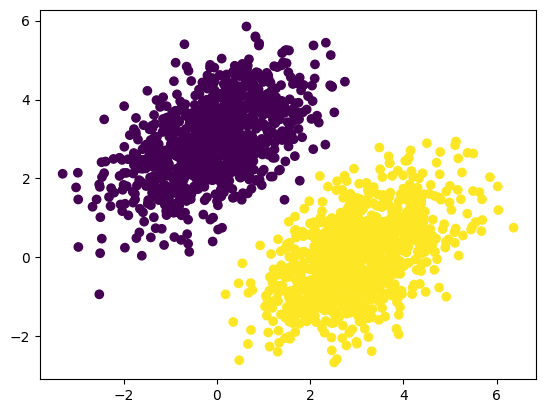

In [44]:
import tensorflow as tf

# Define input and output dimensions
input_dim = 2   # because each input is a 2D point (x, y)
output_dim = 1  # single score per sample

# Initialize weights and bias
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
#creates a tensor filled with random numbers.btn 0 & 1
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))
#creates a tensor filled with zeros.
#tf.variable make it a mutable variable (so it can be updated during training).
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b
    #perform matrix multi and add +b shift thr boundary
    # Loss function
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    # difference squared
    return tf.reduce_mean(per_sample_losses)
    # average loss
# Training step
learning_rate = 0.1

#unclear have to see these last part
@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)              # forward pass
        loss = mean_squared_error(targets, predictions) # compute loss
    # compute gradients of loss w.r.t W and b
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    # update weights and bias
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

    # Batch training loop
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")
    # Batch training loop
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

    import matplotlib.pyplot as plt
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()